In [1]:
import os
import numpy as np
import pymc as pm
import pytensor

pytensor.config.cxx = '/usr/bin/clang++'

max_iters = int(os.environ.get("SIMPLEVI_PYMC_DEMO_ITERS", "300000"))


In [2]:
mu_prior, sigma_prior = 0, 10
sigma_like = 1.0
with pm.Model() as single_model:
    # Define priors
    mu = pm.Normal("mu", mu_prior, sigma_prior)
    likelihood = pm.Normal('y', mu=mu, sigma=sigma_like, observed=np.array([]))
    advi = pm.ADVI(random_seed=22)
    single_tracker = pm.callbacks.Tracker(
            mean = advi.approx.mean.eval,
            std = advi.approx.std.eval
        )
    single_fit = advi.fit(
        max_iters, callbacks=[single_tracker])

with pm.Model() as multi_model:
    # Define priors
    mu = pm.Normal("mu", mu_prior, sigma_prior)
    likelihood = pm.Normal('y', mu=mu, sigma=sigma_like, observed=np.array([]))
    advi_2 = pm.ADVI(random_seed=10)
    multi_tracker = pm.callbacks.Tracker(
            mean = advi_2.approx.mean.eval,
            std = advi_2.approx.std.eval
        )
    multi_fit = advi_2.fit(
        max_iters, callbacks=[multi_tracker],
        obj_n_mc=100)

Output()

Finished [100%]: Average Loss = 0.0062518


Output()

Finished [100%]: Average Loss = 5.8325e-07


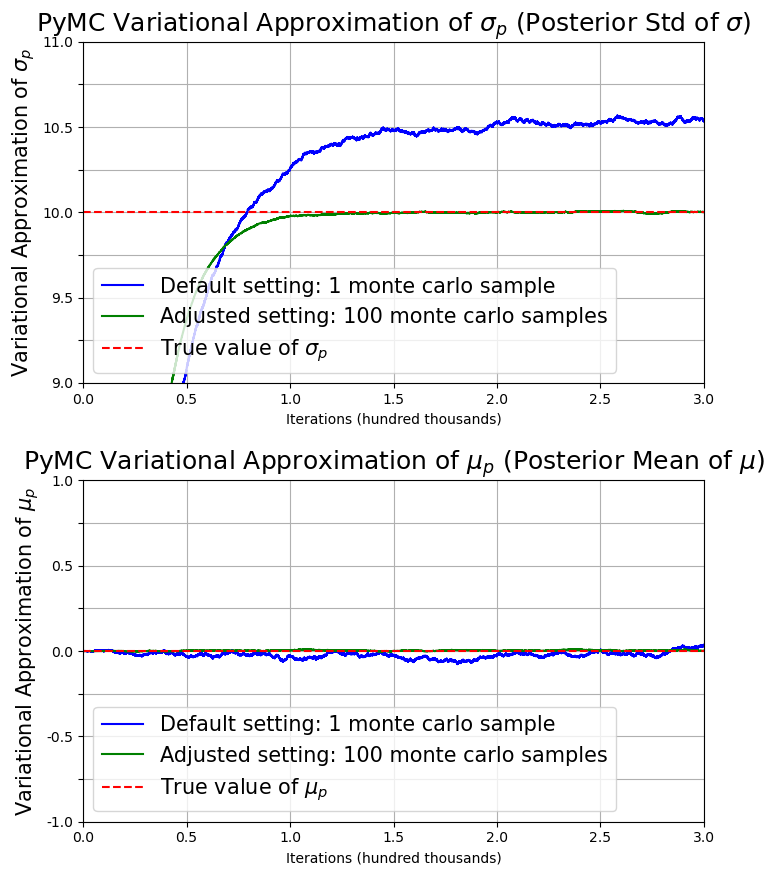

In [3]:
# plot single_tracker vs multi_tracker for the mean and std of mu
# add dashed lines for true values of mu mean and std which is N(0, 1)
from modulars.plot_rr import plot_3_1_trajectories
plot_3_1_trajectories(
    single_tracker['mean'],
    single_tracker['std'],
    multi_tracker['mean'],
    multi_tracker['std'],
    framework_name='PyMC',
    max_iters=max_iters,
    true_mu=mu_prior, # since no observations, posterior is equal to prior
    true_sigma=sigma_prior,
    MILLIONS=False
)


# What about with the adam optimizer?

In [4]:
mu_prior, sigma_prior = 0, 10
sigma_like = 1.0
optimizer = pm.adam()
with pm.Model() as single_model:
    # Define priors
    mu = pm.Normal("mu", mu_prior, sigma_prior)
    likelihood = pm.Normal('y', mu=mu, sigma=sigma_like, observed=np.array([]))
    advi = pm.ADVI(random_seed=22)
    single_tracker = pm.callbacks.Tracker(
            mean = advi.approx.mean.eval,
            std = advi.approx.std.eval
        )
    single_fit = advi.fit(
        max_iters, callbacks=[single_tracker],
        obj_optimizer=optimizer,)

with pm.Model() as multi_model:
    # Define priors
    mu = pm.Normal("mu", mu_prior, sigma_prior)
    likelihood = pm.Normal('y', mu=mu, sigma=sigma_like, observed=np.array([]))
    advi_2 = pm.ADVI(random_seed=10)
    multi_tracker = pm.callbacks.Tracker(
            mean = advi_2.approx.mean.eval,
            std = advi_2.approx.std.eval
        )
    multi_fit = advi_2.fit(
        max_iters, callbacks=[multi_tracker],
        obj_n_mc=100,
        obj_optimizer=optimizer,)

Output()

Finished [100%]: Average Loss = 0.00020149


Output()

Finished [100%]: Average Loss = 8.6562e-06


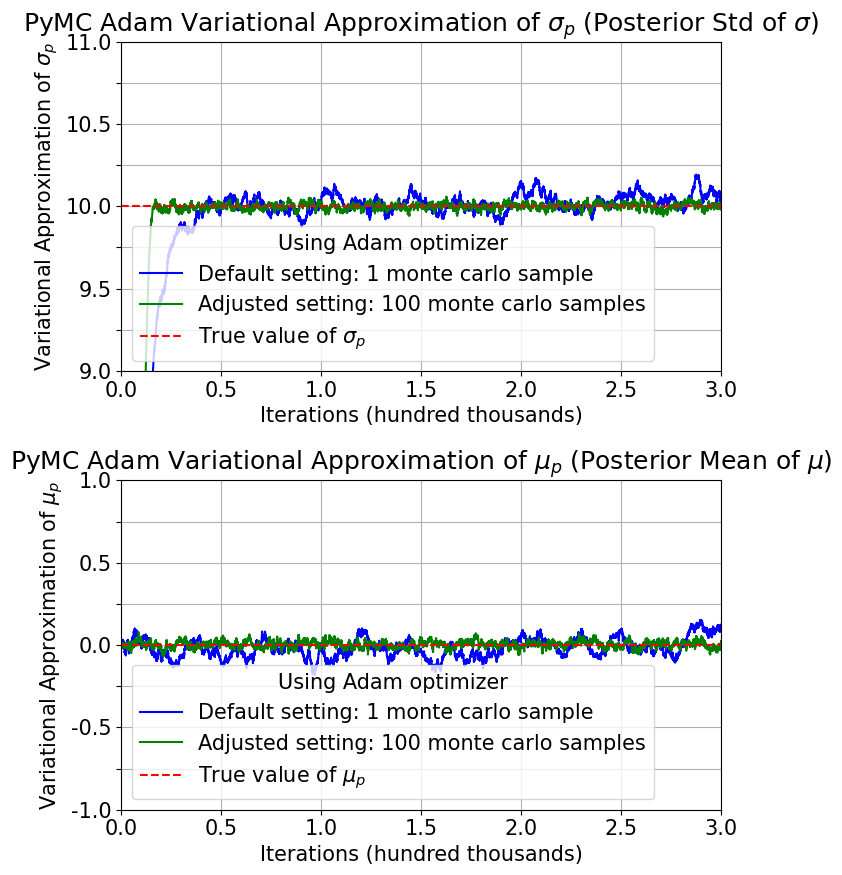

In [5]:

plot_3_1_trajectories(
    single_tracker['mean'],
    single_tracker['std'],
    multi_tracker['mean'],
    multi_tracker['std'],
    framework_name='PyMC',
    max_iters=max_iters,
    true_mu=mu_prior, # since no observations, posterior is equal to prior
    true_sigma=sigma_prior,
    MILLIONS=False,
    PYMC_ADAM=True
)
